<a target="_blank" href="https://colab.research.google.com/github/ClaudioSalvatoreArcidiacono/felimination/blob/main/docs/tutorials/genetic_algorithms_x_mrmr_mutation.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Genetic Algorithms x MRMR: Smarter Mutation Candidate Selection

This tutorial shows how to combine the genetic-algorithm feature selector with the
**MRMR (Minimum Redundancy Maximum Relevance)** ranker to make the mutation step smarter.

In the standard GA flow, when a solution is mutated (a feature is swapped in or out), the
replacement candidate is chosen at random from the pool of unselected features.
By passing an [`MRMRRanker`](https://claudiosalvatorearcidiacono.github.io/felimination/reference/selectors/MRMR/#felimination.mrmr.MRMRRanker)
as the `mutation_candidate_scorer`, the selector instead scores every candidate feature
**relative to what is already in the solution being mutated** — features that are highly
relevant to the target *and* not yet well-represented in the current feature set are
ranked first.

This leads to mutations that explore the search space more intelligently: instead of
randomly swapping in a correlated copy of a feature that is already selected, the ranker
steers the mutation toward genuinely complementary features.

In [ ]:
# Install felimination
! pip install felimination

## How MRMR-guided mutation works

At each mutation step, `HybridImportanceGACVFeatureSelector` picks a solution from the
pool and swaps one of its features for a candidate from outside the solution.  When
`mutation_candidate_scorer` is set, the scoring function is called with:

```
scorer(X, y, selected_features) -> array of shape (n_features,)
```

where `selected_features` is the list of feature indices **already in that particular
solution**.  `MRMRRanker` uses this list to compute the MRMR score for every feature:

- **Relevance** — mutual information between the candidate feature and the target `y`.
- **Redundancy** — average mutual information between the candidate and each already-selected feature.

The score is `relevance / redundancy` (or `relevance - redundancy` for the `"difference"`
scheme).  Features that are relevant but not redundant with the current selection rank
highest and are therefore the most likely mutation candidates.

The `mutation_candidate_selection` parameter controls how the ranked list is used:

| Value | Behaviour |
|---|---|
| `"best"` | Always pick the top-ranked candidate (deterministic). |
| `"sample"` | Sample proportionally to the score (stochastic; default). |

`"sample"` is usually preferable because it preserves diversity — the best candidate is
picked most often but lower-ranked ones still get a chance, keeping the population from
collapsing prematurely.

## Create a dummy dataset

We use the same dataset as in the
[Genetic Algorithms x Feature Selection](genetic_algorithms_x_feature_selection.ipynb)
tutorial so that results are directly comparable: 200 features in total, of which 6 are
informative, 10 are redundant (correlated with the informative ones), and the remaining
184 are pure noise.

In [29]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=1000,
    n_features=200,
    n_informative=6,
    n_redundant=10,
    n_clusters_per_class=1,
    random_state=42,
    shuffle=False,
)

## Baseline: performance without feature selection

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

model = LogisticRegression(random_state=42)
cv = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

cv_results = cross_validate(model, X, y, cv=cv, scoring="roc_auc", return_train_score=True)
print(f"Baseline AUC: {cv_results['test_score'].mean():.4f}")

Baseline AUC: 0.8561


## Standard GA (random mutation)

First we run the GA with its default random mutation, as a reference point.

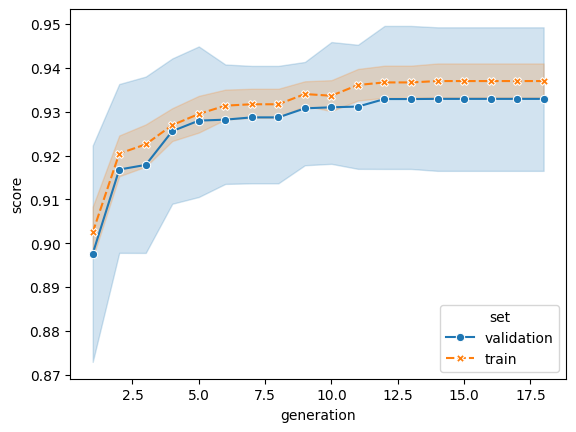

,estimator,LogisticRegre...ndom_state=42)
,cv,StratifiedKFo... shuffle=True)
,scoring,'roc_auc'
,random_state,42
,n_jobs,None
,importance_getter,'auto'
,min_features_to_select,3
,init_avg_features_num,5
,init_std_features_num,5
,pool_size,20
,is_parent_selection_chance_proportional_to_fitness,True


In [36]:
from felimination.callbacks import plot_progress_callback
from felimination.ga import HybridImportanceGACVFeatureSelector

selector_random = HybridImportanceGACVFeatureSelector(
    model,
    callbacks=[plot_progress_callback],
    scoring="roc_auc",
    cv=cv,
    init_avg_features_num=5,
    min_features_to_select=3,
    pool_size=20,
    n_children_cross_over=20,
    n_mutations=20,
    patience=5,
    random_state=42,
    range_randomly_swapped_features_mutation=(1, 5)
)
selector_random.fit(X, y)

In [37]:
print(f"Best AUC (random mutation): {selector_random.best_solution_['mean_test_score']:.4f}")
print(f"Features selected: {sorted(selector_random.best_solution_['features'])}")

Best AUC (random mutation): 0.9329
Features selected: [np.int64(6), np.int64(8), np.int64(10), np.int64(14), np.int64(15), 69, np.int64(82), 113, np.int64(197)]


## GA with MRMR mutation scorer

Now we pass an `MRMRRanker` as `mutation_candidate_scorer`.  The ranker is
**stateful and lazy**: relevance scores are computed once on the first call and reused;
per-feature redundance vectors are filled on demand and cached, so features that appear
in many solutions only pay the computation cost once.

We use `mutation_candidate_selection="sample"` so that the mutation remains stochastic
but biased toward high-scoring candidates.

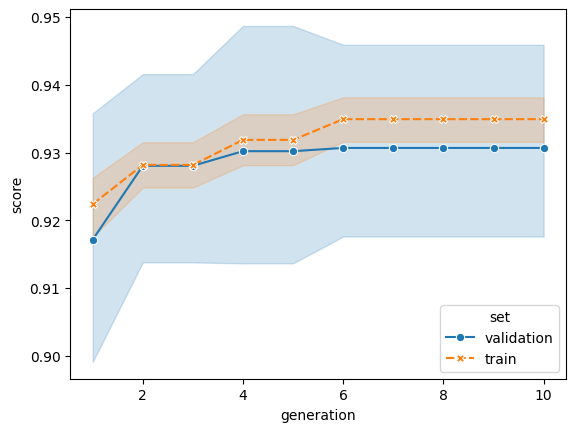

,estimator,LogisticRegre...ndom_state=42)
,cv,StratifiedKFo... shuffle=True)
,scoring,'roc_auc'
,random_state,42
,n_jobs,None
,importance_getter,'auto'
,min_features_to_select,3
,init_avg_features_num,5
,init_std_features_num,5
,pool_size,20
,is_parent_selection_chance_proportional_to_fitness,True


In [38]:
from felimination.mrmr import MRMRRanker

mrmr_ranker = MRMRRanker(regression=False, random_state=42)

selector_mrmr = HybridImportanceGACVFeatureSelector(
    model,
    callbacks=[plot_progress_callback],
    scoring="roc_auc",
    cv=cv,
    init_avg_features_num=5,
    min_features_to_select=3,
    pool_size=20,
    n_children_cross_over=20,
    n_mutations=20,
    mutation_candidate_scorer=mrmr_ranker,
    mutation_candidate_selection="sample",
    random_state=42,
    patience=5,
    range_randomly_swapped_features_mutation=(1, 5)
)
selector_mrmr.fit(X, y)

In [39]:
print(f"Best AUC (MRMR mutation): {selector_mrmr.best_solution_['mean_test_score']:.4f}")
print(f"Features selected: {sorted(selector_mrmr.best_solution_['features'])}")

Best AUC (MRMR mutation): 0.9307
Features selected: [np.int64(6), np.int64(8), np.int64(10), 11, 12, 105, 159, 168, np.int64(197)]


## Compare results

Let's put the numbers side by side.

In [40]:
import pandas as pd

results = pd.DataFrame(
    {
        "Setup": ["Baseline (all features)", "GA (random mutation)", "GA (MRMR mutation)"],
        "AUC": [
            cv_results["test_score"].mean(),
            selector_random.best_solution_["mean_test_score"],
            selector_mrmr.best_solution_["mean_test_score"],
        ],
        "n_features": [
            X.shape[1],
            len(selector_random.best_solution_["features"]),
            len(selector_mrmr.best_solution_["features"]),
        ],
        "n_iterations": [
            0,
            len(selector_random.best_solutions_),
            len(selector_mrmr.best_solutions_),
        ],
    }
).set_index("Setup")

results

,AUC,n_features,n_iterations
Setup,,,
Baseline (all features),0.856136,200,0
GA (random mutation),0.932938,9,18
GA (MRMR mutation),0.930678,9,10


## Why does MRMR guidance help?

In this dataset, 10 of the 200 features are linear combinations of the 6 informative
ones — they carry similar signal but add redundancy.  Random mutation has no way to
distinguish them from features that add genuinely new information.  The MRMR scorer,
on the other hand, penalises candidates that are highly correlated with features already
in the solution, so it naturally avoids swapping in a redundant copy when a complementary
feature is available.

The result is a search that tends to reach good solutions in fewer generations, because
fewer mutations are "wasted" on substitutions that do not change the information content
of the selected set.